In [1]:
file_path = "C:/Users/da3ma/OneDrive/Desktop/Internships/codealpha/Task 3/Advertising.csv"

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv(file_path)

In [4]:
df.head()

,id,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.isnull().sum()

id           0
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [6]:
df.drop('id', axis=1, inplace=True)

In [7]:
sns.set_theme(style="whitegrid")

palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13
})

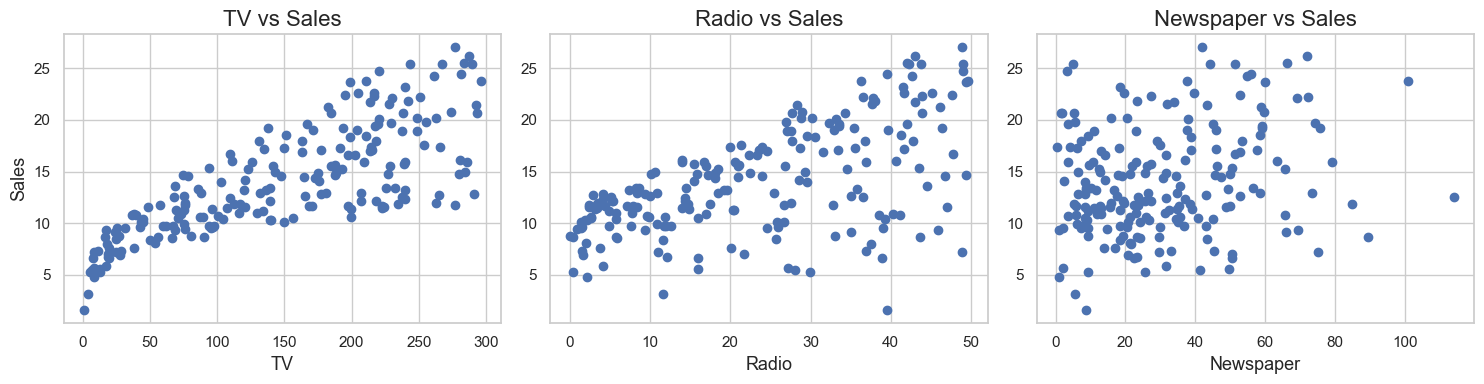

In [8]:
plt.figure(figsize=(15,4))

# TV
plt.subplot(1,3,1)
plt.scatter(df['TV'], df['Sales'])
plt.title('TV vs Sales')
plt.xlabel('TV')
plt.ylabel('Sales')

# Radio
plt.subplot(1,3,2)
plt.scatter(df['Radio'], df['Sales'])
plt.title('Radio vs Sales')
plt.xlabel('Radio')

# Newspaper
plt.subplot(1,3,3)
plt.scatter(df['Newspaper'], df['Sales'])
plt.title('Newspaper vs Sales')
plt.xlabel('Newspaper')

plt.tight_layout()
plt.show()

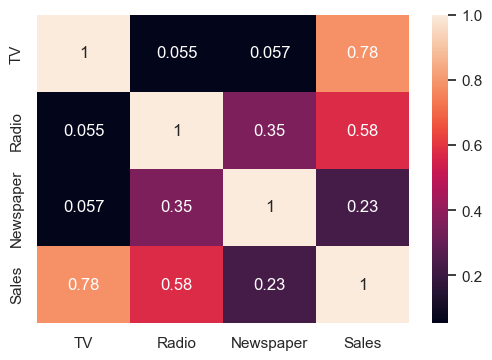

In [9]:
corr = df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.show()

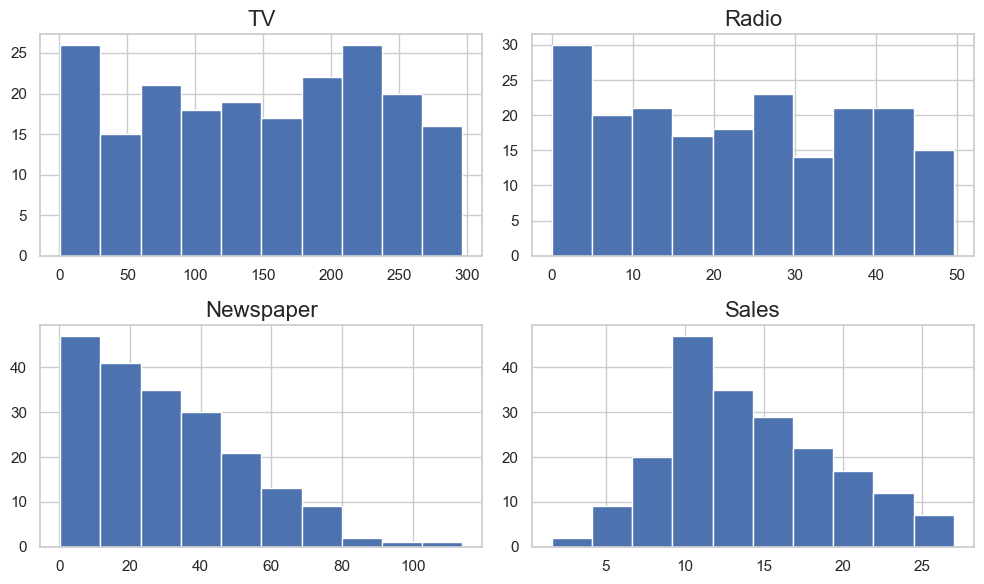

In [10]:
df.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

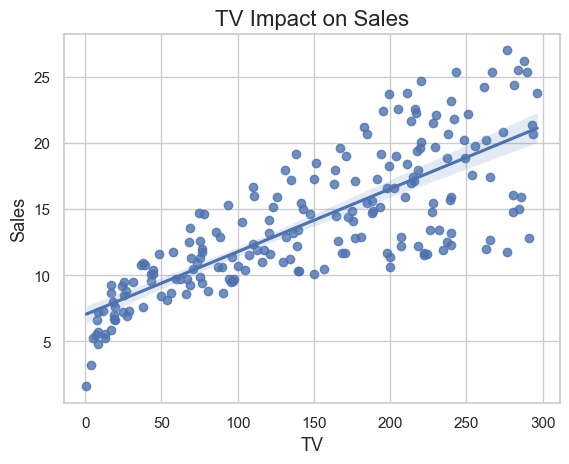

In [11]:
sns.regplot(x='TV', y='Sales', data=df)
plt.title("TV Impact on Sales")
plt.show()

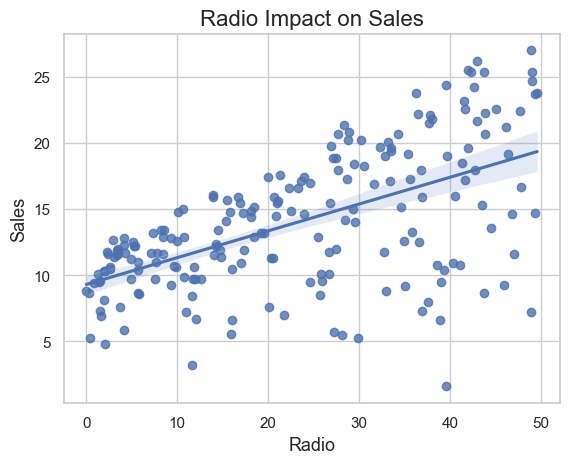

In [12]:
sns.regplot(x='Radio', y='Sales', data=df)
plt.title("Radio Impact on Sales")
plt.show()

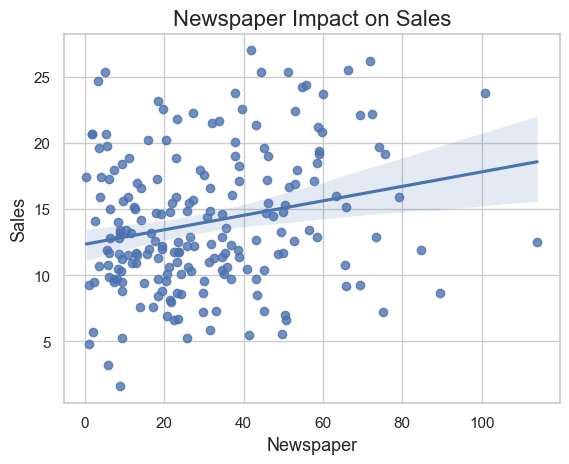

In [13]:
sns.regplot(x='Newspaper', y='Sales', data=df)
plt.title("Newspaper Impact on Sales")
plt.show()

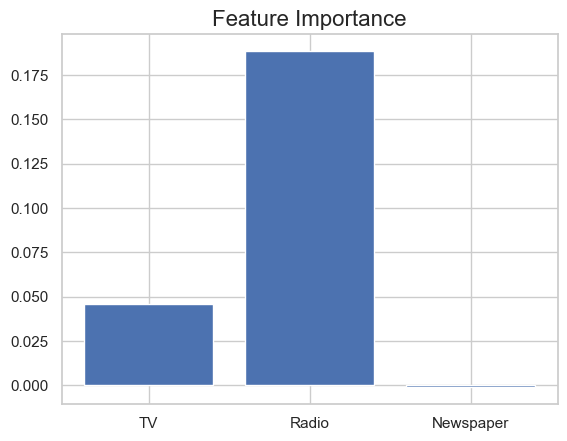

In [14]:
from sklearn.linear_model import LinearRegression

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

importance = model.coef_

plt.bar(['TV', 'Radio', 'Newspaper'], importance)
plt.title("Feature Importance")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

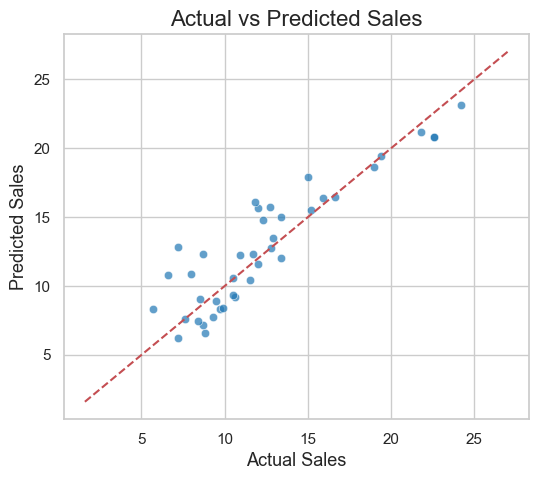

In [17]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_test, y=y_pred, color="#1f77b4", alpha=0.7)

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 4.247501578696829
RMSE: 2.060946767555346
MAE: 1.5728490333384064
R2: 0.8042693085716554
